# Disclaimer

This is an early version of a Chapter on gate-based quantum computing with neutral-atoms that we are currently developing. As participants of YQuantum, you are getting early access to it.

If something is not clear, it is probably our fault. Come talk to the team about and we will be happy to help you out!

# Quantum Circuits with Bloqade

You already heard a little bit about the physics that makes quantum computing with neutral atoms possible, along with the key characteristics of our gate-based systems. In this tutorial, we turn to building and simulating quantum circuits using Bloqade, QuEra's software toolkit for programming neutral-atom computers.

By the end of this chapter, you will be able to:
- **Use** the tools in QuEra's Bloqade to build and test quantum programs
- **Remember** the hierarchy of error sources in neutral-atom programs
- **Reflect** on the design principles for efficient neutral-atom programs
- **Execute** noisy simulations with hardware-aware heuristic noise models

In [1]:
from typing import Any

from kirin.ir import Method
import matplotlib.pyplot as plt
import numpy as np

from bloqade import squin, tsim
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
from kirin.dialects.ilist import IList
import matplotlib.pyplot as plt

# this will help us have return types for our methods that have more intuitive names
Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

# this function will help us visualize some circuits
def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)

# Bloqade: the Software Development Kit for neutral-atom computers
QuEra is actively developing Bloqade, an open-source software development kit (SDK) that serves as a hub for creating neutral-atom programs.
Inside Bloqade there are several modules and domain-specific languages (DSLs).
Each module and DSL is tailored to a different stage of building quantum programs.
Bloqade is also built on top of Kirin (Kernel Intermediate Representation Infrastructure), QuEra's open-source compiler infrastructure for quantum computing.

In this course, we focus on the modules and DSLs used to build digital programs. The two main components on Bloqade's digital side are Bloqade Circuit and Bloqade Lanes. Bloqade Circuit contains the tools needed to build quantum circuits, while Bloqade Lanes contains the tools needed to control atom moves. In this chapter, we focus on Bloqade Circuit and the SQUIN (Structural Quantum Instructions) DSL.

Bloqade also includes tools for building analog neutral-atom programs. For the rest of this chapter, however, we focus on digital programs. If you would like to learn more about Bloqade Analog and its capabilities, please refer to the QBook course on using our Aquila (analog) system.

</br>
<div align="center">
  <img src="./bloqade.png" width="1000">
</div>
</br>

## Building your first circuit in Bloqade
Our first hands-on step is to build a simple Bell-state preparation circuit using `squin`, Bloqade's circuit-level language for gate-based programs. This is a natural starting point because the Bell state is one of the simplest entangled states, yet it already shows the core ingredients of circuit design on gate-based systems: qubit allocation, single-qubit rotations, and a two-qubit entangling gate.

> **Python note: decorators**
>
> In Python, a **decorator** modifies the behavior of a function by placing `@something` directly above its definition. When Python reads the function, it passes that function to the decorator and replaces it with the decorated version.
>
> In `squin`, we use the decorator `@squin.kernel` to tell Bloqade that the function should be treated as a quantum kernel rather than as an ordinary Python function. This allows Bloqade to capture the function, lower it into its internal representation, and then run or analyze it using Bloqade's quantum toolchain.

In [3]:
@squin.kernel
def bell_state() -> Measurement:
    qubits = squin.qalloc(2)
    squin.h(qubits[0])
    squin.cx(qubits[0], qubits[1])
    bits = squin.broadcast.measure(qubits)
    return bits

This short example already shows how to identify the main building blocks of a `squin` kernel.

1. **Qubit allocation**: `squin.qalloc(2)` creates a register containing two qubits. When you read a kernel, this is usually the first thing to look for, because it tells you how many qubits the routine is using.
2. **Gate applications**: lines such as `squin.h(qubits[0])` and `squin.cx(qubits[0], qubits[1])` are the quantum operations that transform the state. In practice, reading these lines from top to bottom tells you the logical flow of the circuit.
3. **Register-wide operations**: `squin.broadcast.measure(qubits)` applies the same kind of operation to all qubits in the register at once. More generally, `squin.broadcast.[gate]` is useful whenever we want to act on several qubits in parallel.
4. **Returned values**: the `return` statement tells us what information the kernel gives back after execution. In this example, the output is the pair of measurement results rather than the qubits themselves.

A useful rule of thumb is therefore: when reading a `squin` kernel, first locate the qubit allocation, then the gate sequence, then any measurements, and finally the returned object. That is usually enough to understand the role of the kernel at a high level.

Now, we can optionally visualize the quantum circuit that results from this kernel. We have created the helper function `show_circuit` to be used throughout this chapter. In the next chapter we will discuss more carefully what is happening when we call this helper function so for now you should not worry about how it works.

In [4]:
show_circuit(bell_state)

To test circuits locally, Bloqade integrates naturally with `pyqrack`, a fast simulation backend for quantum programs. In practice, this makes it easy to take a `squin` kernel and run it inside Bloqade with only a small amount of additional code, which is useful for quickly validating circuit behavior before moving on to larger examples.

---

In [5]:
pyqrack_target = StackMemorySimulator(min_qubits=2)
task = pyqrack_target.task(bell_state)

single_shot = task.run()
single_shot

IList([<Measurement.One: 1>, <Measurement.One: 1>])

A call to `task.run()` executes a single shot of the circuit and returns the same type of object specified in the kernel output: here, a two-entry list-like collection of measurement objects, one for each qubit. In the computational basis, the Bell-state preparation should ideally produce either $\ket{00}$ or $\ket{11}$. Because the Bell state yields these two outcomes with equal probability, we expect to observe $\ket{00}$ about 50% of the time and $\ket{11}$ about 50% of the time. That statistical structure is hard to appreciate from only one or two shots, so next we run a larger batch.

In [6]:
batch_results = task.batch_run(shots=200)
batch_results

{(<Measurement.One: 1>, <Measurement.One: 1>): 0.52,
 (<Measurement.Zero: 0>, <Measurement.Zero: 0>): 0.48}

---

## Using kernels as subroutines: a quantum teleportation example

Quantum teleportation is a protocol for transferring an unknown quantum state $\ket{\psi}$ from one wire to another without physically moving the qubit that initially stores the state. The basic ingredients are an input qubit prepared in $\ket{\psi}$ and a Bell pair shared between two additional wires. One of the Bell-pair qubits is brought together with the input qubit, measured in an entangling basis, and the measurement outcomes are sent forward as classical information. After the appropriate correction is applied to the remaining Bell-pair qubit, that last wire ends up in the original state $\ket{\psi}$.

This is a natural place to reuse our Bell-state preparation routine as a subroutine. The only small change we need is to stop measuring the Bell-pair qubits at the end. Instead, we return the register so those qubits remain available for the rest of the teleportation circuit.

In [7]:
@squin.kernel
def bell_state_prep() -> Register:
    qubits = squin.qalloc(2)
    squin.h(qubits[0])
    squin.cx(qubits[0], qubits[1])
    return qubits

show_circuit(bell_state_prep)

To keep the example simple, we introduce a very small kernel called `psi`. Its only purpose is to act as a proxy for an input state that could just as well have come from some other program. In other words, `psi` is a stand-in for "whatever one-qubit state we want to teleport."

In [8]:
@squin.kernel
def psi() -> Register:
    qubits = squin.qalloc(1)
    # these are just some example operations with random parameters
    squin.ry(0.67, qubits[0])
    squin.rz(0.42, qubits[0])
    return qubits

show_circuit(psi)

Now we can define the `teleport` kernel by calling `bell_state_prep` and `psi` as subroutines. In the example below, `teleport` does not need to allocate a register with `squin.qalloc` because the subroutines each return registers. An alternative version of the kernel could allocate a 3-qubit register directly and pass the corresponding subregisters to versions of the subroutines that take a qubit register as input.

In [9]:
@squin.kernel
def teleport() -> Register:
    input_register = psi()
    bell_register = bell_state_prep()

    squin.cx(input_register[0], bell_register[0])
    squin.h(input_register[0])

    mid_circuit_measurement = squin.broadcast.measure([input_register[0], bell_register[0]])

    if mid_circuit_measurement[0]:
        squin.z(bell_register[1])
    if mid_circuit_measurement[1]:
        squin.x(bell_register[1])
    
    return [bell_register[1]] # we created a list contaning the target qubit so that the output type is Register

# the function we created for you cannot visualize mid-circuit
# measurements but you will soon see why this is not a problem

To confirm that teleportation worked, we can compare the state produced directly by `psi` with the output qubit returned by `teleport`. A convenient way to do this in simulation is to compare their reduced density matrices. This is a robust check because two statevectors can differ by an overall global phase and still represent the same physical quantum state.

In [10]:
psi_simulator = StackMemorySimulator(min_qubits=1)
psi_task = psi_simulator.task(psi)
psi_state = psi_task.run()
rho_psi = StackMemorySimulator.reduced_density_matrix(psi_state)

teleport_simulator = StackMemorySimulator(min_qubits=3)
teleport_task = teleport_simulator.task(teleport)
psi_prime = teleport_task.run()
rho_psi_prime = StackMemorySimulator.reduced_density_matrix(psi_prime)

print("Density matrix of psi:")
print(rho_psi)
print()
print("Density matrix of psi_prime:")
print(rho_psi_prime)
print()
print("Do the two states match?", np.allclose(rho_psi, rho_psi_prime))

Density matrix of psi:
[[0.89191084-0.j         0.28350771-0.12660677j]
 [0.28350771+0.12660677j 0.10808916-0.j        ]]

Density matrix of psi_prime:
[[0.89191097+0.j         0.28350776-0.12660677j]
 [0.28350776+0.12660677j 0.10808918-0.j        ]]

Do the two states match? True


---



## Using Postselection

We can also study teleportation without applying the conditional corrections inside the circuit. In that case, we still perform the two measurements that identify the teleportation branch, but instead of using those outcomes to decide whether to apply $X$ and $Z$, we record them and analyze the results afterward.

For the teleportation protocol to succeed without any corrections, the measurement outcome for the first two qubits must be $00$. Such an outcome means that the output qubit is already in the desired state $\ket{\psi}$. The other three possibilities ($01$, $10$, and $11$) also contain the teleported state, but only up to known Pauli operations. A postselection experiment therefore proceeds by repeating the circuit many times, keeping only the shots with measurement outcome $00$, and then comparing the corresponding output state with the state produced directly by `psi`.

This provides a useful comparison with the feedforward version above: there, every shot is actively corrected, while here we retain only the shots that already fall in the correct branch.

In [11]:
@squin.kernel
def teleport_postselect() -> int:
    # same code as before
    input_register = psi()
    bell_register = bell_state_prep()

    squin.cx(input_register[0], bell_register[0])
    squin.h(input_register[0])

    mid_circuit_measurement = squin.broadcast.measure([input_register[0], bell_register[0]])
    
    # now we skip the correction step and return the bitwise OR of the measurement outcomes
    return mid_circuit_measurement[0] | mid_circuit_measurement[1]

show_circuit(teleport_postselect)

In the kernel above, the bitwise OR of the measurements will be $0$ if and only if both qubits are measured in the $\ket{0}$ state, and $1$ otherwise. The cases in which this value equals $0$ are exactly the ones we want to keep in a postselection experiment. After each run, we can inspect that value and retain only the shots for which `teleport_postselect` returns $0$.

Because this example is noiseless, all of the successful shots will match $\ket{\psi}$ up to negligible rounding errors. In a realistic setting, however, it is often useful to average the density matrices obtained across the postselected shots. Even though that averaging is not strictly necessary here, we will do it now because we will reuse the same approach in the experiments that follow.

In [12]:
def estimate_postselected_rate_and_density_matrix(postselect_task, shots: int):
    successful_density_matrices = []

    for _ in range(shots):
        case = postselect_task.run()
        if case == 0:
            # we retrieve the target qubit from the task and wrap it in a list so that the output type is Register
            psi_prime = [postselect_task.qubits()[2]]
            successful_density_matrices.append(
                StackMemorySimulator.reduced_density_matrix(psi_prime)
            )

    if not successful_density_matrices:
        raise RuntimeError("No postselected shots were found. Try increasing total_shots.")
        
    postselection_rate = len(successful_density_matrices) / shots
    rho_postselected = np.mean(successful_density_matrices, axis=0)
    return postselection_rate, rho_postselected

---


In [13]:
postselect_simulator = StackMemorySimulator(min_qubits=3)
postselect_task = postselect_simulator.task(teleport_postselect)
total_shots = 200
postselection_rate, rho_postselected = estimate_postselected_rate_and_density_matrix(postselect_task=postselect_task, shots=total_shots)

print(f"Postselection rate: {100 *postselection_rate:.2f}%")
print("Postselected shots:", round(total_shots * postselection_rate), "out of", total_shots)
print()
print("Density matrix of psi:")
print(rho_psi)
print()
print("Density matrix of postselected psi_prime:")
print(rho_postselected)
print()
print("Do the two states match?", np.allclose(rho_psi, rho_postselected))

Postselection rate: 24.00%
Postselected shots: 48 out of 200

Density matrix of psi:
[[0.89191084-0.j         0.28350771-0.12660677j]
 [0.28350771+0.12660677j 0.10808916-0.j        ]]

Density matrix of postselected psi_prime:
[[0.89191084+0.j         0.28350772-0.12660676j]
 [0.28350772+0.12660676j 0.10808917+0.j        ]]

Do the two states match? True


---

# Simulating Noise
## Recap

So far we have treated our circuits as perfectly coherent. Real neutral-atom programs, however, are always affected by noise. The table below provides a quick recap of the main contributions we will keep in mind in this chapter.

</br>
<div align="center">
  <img src="./error_sources_recap.png" width="1000">
</div>
</br>

| Error source | Typical order of magnitude | Bias |
|---|---|---|
| Two-qubit gate (paired or entangled atoms) | $10^{-3}$ | $Z$-bias |
| Two-qubit gate (unpaired or spectator atom) | $10^{-3}$ | $Z$-bias |
| Moving atom(s) | $10^{-3}$ | $Z$-bias |
| Sitting atom(s) while other atom(s) move | $10^{-4}$ | - |
| Local one-qubit gate | $10^{-4}$ | - |
| Global one-qubit gate | $10^{-5}$ | - |

## Noisy Teleportation
Let us now build a simplified circuit-level noise model while temporarily disregarding errors associated with rearranging the neutral atoms. Using the `depolarize` and `depolarize2` noise "gates" in `squin`, which introduce one-qubit and two-qubit depolarizing channels respectively, we can simulate noise seeping into our Bell-state subroutine after each ideal gate.

In the Bell-state preparation circuit, we will add a `depolarize` gate after the single-qubit Hadamard gate and a `depolarize2` gate after the CX gate. For now, we set the noise probability $p$ for both depolarizing channels to 0.1, or 10%, so that the effect of noise seeping from a subroutine into the main program is easy to see.

> **Python note: closures**
>
> In Python, a **closure** is a function created inside another function that remembers variables from the surrounding scope. In the example below, the inner kernel remembers the value of `noise_probability` even after the outer function has finished running.
>
> This is useful here because we want to generate several versions of the same Bell-state preparation routine while changing only one ingredient: the amount of noise. A closure lets us keep the circuit structure fixed while creating a family of related kernels parameterized by the chosen noise strength.

In [14]:
def make_noisy_bell_state_prep(noise_probability: float):
    @squin.kernel
    def noisy_bell_state_prep() -> Register:
        qubits = squin.qalloc(2)
        squin.h(qubits[0])
        squin.depolarize(p=noise_probability, qubit=qubits[0])
        squin.cx(qubits[0], qubits[1])
        squin.depolarize2(p=noise_probability, control=qubits[0], target=qubits[1])
        return qubits
    return noisy_bell_state_prep

show_circuit(make_noisy_bell_state_prep(noise_probability=0.1))

Because teleportation calls the Bell-pair routine as a subroutine, any noise inserted there is automatically inherited by the larger protocol. The input state `psi` may still be prepared cleanly, but the entangled resource used to move that state across the circuit is now imperfect. As a result, even after postselection, we should expect the recovered output state to deviate from the ideal one.

In [15]:
def make_teleport_postselect_noisy(noise_probability: float):
    noisy_bell_state_prep = make_noisy_bell_state_prep(noise_probability)
    @squin.kernel
    def teleport_postselect_noisy() -> int:
        input_register = psi()
        bell_register = noisy_bell_state_prep()
        squin.cx(input_register[0], bell_register[0])
        squin.h(input_register[0])

        measurement = squin.broadcast.measure([input_register[0], bell_register[0]])
        return measurement[0] | measurement[1]
    
    return teleport_postselect_noisy

show_circuit(make_teleport_postselect_noisy(noise_probability=0.1))


We now define a function, `estimate_postselected_overlap`, that estimates the overlap between the density matrix of the teleported qubit when postselection succeeds and the original density matrix associated with `psi`, namely `rho_psi`. Here we use the overlap with `rho_psi` as a simple figure of merit. A value near $100\%$ means the teleported state is still very close to the target, while smaller values indicate that errors introduced in the Bell-pair subroutine are propagating into the final result. Once the overlap falls too far, the output is no longer reliable enough to support a meaningful computation.

In [17]:
postselect_simulator = StackMemorySimulator(min_qubits=3)
postselect_task = postselect_simulator.task(teleport_postselect)
total_shots = 1000
postselection_rate, rho_postselected = estimate_postselected_rate_and_density_matrix(postselect_task=postselect_task, shots=total_shots)

def estimate_postselected_overlap(noise_probability: float, shots: int, rho: np.ndarray):
    postselect_simulator = StackMemorySimulator(min_qubits=3)
    noisy_postselect_kernel = make_teleport_postselect_noisy(noise_probability=noise_probability)
    postselect_task = postselect_simulator.task(noisy_postselect_kernel)

    _, rho_postselected = estimate_postselected_rate_and_density_matrix(postselect_task=postselect_task, shots=shots)
    overlap = float(np.real(np.trace(rho @ rho_postselected)))
    return overlap

overlap = estimate_postselected_overlap(noise_probability=0.1, shots=200, rho=rho_psi)
print(f"Overlap with psi: {100 * overlap:.2f}%")

Overlap with psi: 93.42%


We can now scan the noise strength and watch how the postselected teleportation output drifts away from the ideal state as the noise in the Bell-state preparation increases.

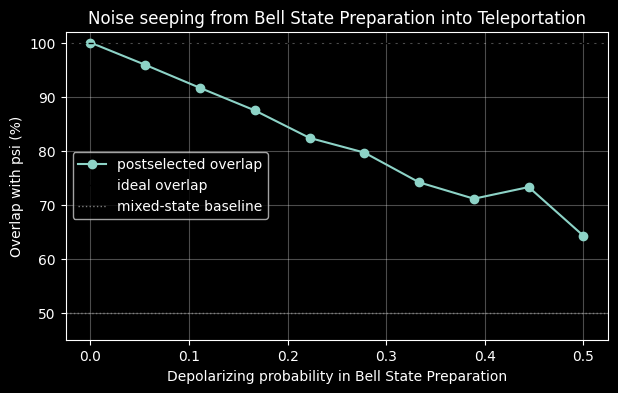

In [18]:
noise_values = np.linspace(0.0, .5, 10)
overlaps = []
success_fractions = []

for noise_value in noise_values:
    overlap = estimate_postselected_overlap(noise_probability=noise_value, shots=1000, rho=rho_psi)
    overlaps.append(overlap * 100)

plt.figure(figsize=(7, 4))
plt.plot(noise_values, overlaps, marker="o", label="postselected overlap")
plt.axhline(100, color="black", linestyle="--", linewidth=1, label="ideal overlap")
plt.axhline(50, color="gray", linestyle=":", linewidth=1, label="mixed-state baseline")
plt.xlabel("Depolarizing probability in Bell State Preparation")
plt.ylabel("Overlap with psi (%)")
plt.title("Noise seeping from Bell State Preparation into Teleportation")
plt.ylim(45, 102)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Although the teleportation protocol itself has not changed, the quality of its Bell-pair subroutine has. Because the full circuit depends on that subroutine, the injected noise accumulates into the final output and reduces the overlap with the desired state. In the low-noise regime, the protocol may still return a useful approximation to $\ket{\psi}$. At higher noise levels, however, the teleported state becomes so degraded that the result is no longer informative. This is why circuit design matters: we want subroutines that are as shallow, well calibrated, and noise resilient as possible, so that the smallest possible amount of error seeps into the larger computation.

## Noise Models

So far we have inserted noise channels directly into `squin` kernels. Bloqade also provides a complementary route through its Cirq interoperability tools. The workflow is:

1. Start from a circuit-like `squin` kernel.
2. Convert it to a `cirq.Circuit` with `cirq_utils.emit_circuit`.
3. Apply a noise model with `noise.transform_circuit`.
4. Convert the noisy circuit back into a `squin` kernel with `cirq_utils.load_circuit`.

This is useful when we want to add a noise model to an entire circuit rather than inserting channels one gate at a time by hand. Although in this course we will not cover how to create custom Cirq noise models, we will show how to use Bloqade's pre-built heuristic models.

Bloqade provides two closely related heuristic models inspired in gate-based neutral atom processors:
- `GeminiOneZoneNoiseModel`: all computation happens in a single zone.
- `GeminiTwoZoneNoiseModel`: qubits move between a gate zone and a storage zone throughout the computation.

In the example below, we apply this `emit -> transform -> load` workflow to the teleportation circuit and compare the postselected output with the ideal state `psi`.

In [19]:
noise_model = noise.GeminiOneZoneNoiseModel()
teleport_cirq = emit_circuit(teleport_postselect, ignore_returns=True) # the flag will ignore the return value of the original kernel

noisy_teleport_cirq = noise.transform_circuit(
    teleport_cirq,
    model=noise_model,
)

noisy_teleport_squin = load_circuit(
    noisy_teleport_cirq,
    kernel_name="teleport_one_zone_noisy",
    register_as_argument=True, # this controls whether the register/sub-register is passed as an argument to the kernel
    return_register=True, # this controls whether the register/sub-register is returned by the kernel
)

@squin.kernel
def one_zone_noisy_teleport() -> int:
    register = squin.qalloc(3)
    register = noisy_teleport_squin(register) # we are loading the noisy kernel as a subroutine
    measurement = squin.broadcast.measure([register[0], register[1]])
    return measurement[0] | measurement[1]


A popular native gateset for gate-based neutral atom machines is the $PhasedXZ+CZ$ gateset. To inject noise accurately, the model will translate the circuit so that it is expressed in this popular native gateset. Only then can it add the corresponding noise channels correctly. This happens automatically during the call to `noise.transform_circuit` when we pass one of the heuristic noise models as an argument. Note also that this step may trigger some circuit optimizations.

We can better understand how the circuit changes throughout these steps by printing the intermediate Cirq circuits and then visualizing the final noisy `squin` kernel. Do not worry yet about the logic of how the noise gates added by the model; we will discuss those in more detail in the next section. For now, focus on how much the circuit changes during the transformation and what are some of the parameters in the noise gates.

In [20]:
print("STEP 1: Emit Squin kernel to cirq")
print(teleport_cirq)
print()
print("STEP 2: Transform circuit")
print(noisy_teleport_cirq)

STEP 1: Emit Squin kernel to cirq
0: ───Ry(0.213π)───Rz(0.134π)───@───H───M───
                                │       │
1: ───H────────────@────────────X───────M───
                   │
2: ────────────────X────────────────────────

STEP 2: Transform circuit
0: ─────────────────────────────────────────────────────────────────────────────────────────A(0.000307,0.000307,0.000464)───────A(0.000515,0.000515,0.00218)──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────A(0.000307,0.000307,0.000464)───────────────────PhXZ(a=0.5,x=0.213,z=0)────────A(0.00041,0.00041,0.000411)───────────────────────────────────A(0.000806,0.000806,0.00246)────@───A(II:0.993, IX:0.000227, IY:0.000227, IZ:0.00151, XI:0.000227, XX:0.000143, XY:0.000143, XZ:0.000143, YI:0.000227, YX:0.000143, YY:0.000143, YZ:0.000143, ZI:0.00151, ZX:0.000143, ZY:0.000143, ZZ:0.00143)───A(0.000806,0.000806,0.00

A closer look into the second timestep (column) of the transformed circuits shows that a `A(0.00041,0.00041,0.000411)` noise gate is being applied on two qubits. The arguments in this gate correspond to the `p_X`, `p_Y`, `p_Z` components of a depolarizing channel, which characterize the depolarizing noise in the channel. In this case, the channel is symmetric across the three axis, up to negligible rounding errors.

Since in the first timestep a single-qubit gate was applied to those same qubits, we can deduce that this noise gate must correspond to the noise resulting from local single-qubit gate application. In fact, the parameters appear to be in order of $10^{-4}$, just as expected for the local single-qubit gate error.

Moving on to the third timestep, we see noise gates being applied on all three qubits. Looking at the next timestep, we can derive that these noise gates in the current timestep must be related to atom re-positioning in preparation for the upcoming two-qubit gate. In fact, we see that one qubit is affected by `A(0.000806,0.000806,0.00246)` while the other two are affected by `A(0.000307,0.000307,0.000464)`. These depolarizing noise channels are not symmetric. In particular, the first one seems to be very $Z$-biased. Taking into account that the leading $p_Z$ parameter is in the order of $10^{-3}$ this must be a mover error. Even though the second gate is also asymmetric, $p_Z$ is comparatively still very close to $p_X$ and $p_Y$. In fact, these are instances of the sitting error (which we think of us unbiased).

Lastly, moving on to the sixth timestep, we see the noise result from the application on a two-qubit gate on the entire zone (we used a a one-zone architecture model to transform this circuit). We can now see a $Z$-biased error on the order of $10^{-3}$ in the unpaired atom, and a $Z$-biased correlated error also in the order of $10^{-3}$ in the paired atoms. We can identify the $Z$-bias in this more complicated correlated noise channel by noticing that the probabilities associated with the $IZ$, $ZI$, and $ZZ$ pauli strings is an order of magnitude higher than the other ones.


---



Now we can simulate the noisy kernel and check its overlap with the original density matrix $\rho$ corresponding to the state $\ket{\psi}$.

In [21]:
noisy_squin_simulator = StackMemorySimulator(min_qubits=3)
noisy_squin_task = noisy_squin_simulator.task(one_zone_noisy_teleport)

postselection_rate, noisy_rho = estimate_postselected_rate_and_density_matrix(
    postselect_task=noisy_squin_task,
    shots=1000,
)

overlap = float(np.real(np.trace(rho_psi @ noisy_rho)))

print(f"Postselection rate: {100 * postselection_rate:.2f}%")
print(f"Overlap with psi: {100 * overlap:.2f}%")

Postselection rate: 26.10%
Overlap with psi: 96.64%


This example shows the full interoperability path in action: we start from a `squin` kernel, emit it to Cirq, transform the whole circuit under `GeminiOneZoneNoiseModel`, load the noisy circuit back into `squin`, and then evaluate the postselected output. For a short three-qubit protocol like teleportation, the change may still be small. However, as circuits become deeper and make heavier use of movement and entangling operations, these effects become increasingly important.

In the next section, we look more closely at how these noise models operate under the hood and how they approximate some of the physical processes that can interfere with the performance of a neutral-atom program.

# Heuristic Noise Models

In this section, we build intuition for how QuEra's heuristic noise models, implemented through Cirq interoperability, work under the hood. To prevent the example circuit, or small variations of it, from being automatically optimized during the emit or transform steps, we use a very simple `squin` kernel written directly in the popular native gateset for gate-based neutral atom quantum computers: $PhasedXZ+CZ$.

In [22]:
@squin.kernel
def heuristic_model_circuit():
    qubits = squin.qalloc(4)
    squin.phased_xz(-np.pi/4, np.pi/2, np.pi/4, qubits[2])
    squin.cz(qubits[0], qubits[1])
    squin.phased_xz(-np.pi/4, np.pi/2, np.pi/2, qubits[3]) # this gate is different from the previous one
    squin.cz(qubits[1], qubits[2])

cirq_heuristic_model_circuit = emit_circuit(heuristic_model_circuit)
print(cirq_heuristic_model_circuit)

0: ───@───────
      │
1: ───@───@───
          │
2: ───────@───


## One-zone Noise Model
We now visualize what happens to the circuit when we inject the heuristic `GeminiOneZoneNoiseModel`. This model rewrites the circuit by adding gates that simulate noise from imperfect operations and atom moves. Recall that one-zone machines are organized into atom site pairs, with a left and a right site in each pair. Two-qubit gates act on the full zone, entangling atoms that occupy the same site pair and, ideally, doing nothing to unpaired atoms.

At a high level, this is the logic the model follows when rewriting the circuit:

1. Assume all qubits start in an unpaired position, on the left site of a site pair.
2. Interleave one- and two-qubit gates. Because the one-zone architecture does not support one- and two-qubit gates happening in parallel during the same timestep, the model divides each timestep into either a one-qubit-gate step or a two-qubit-gate step.
3. For each single-qubit gate moment:
    1. Apply the single-qubit gate(s).
    2. Add noise to the target qubits to simulate imperfections in the operation, with the amount depending on whether the gate is global or local.
4. For each two-qubit gate moment:
    1. Assume that each target qubit must move to the corresponding control qubit's right site before the gate is applied. This results in either a mover or sitter error for all qubits in the register, depending on whether they are relocated or remain stationary in preparation for the two-qubit operation.
    2. Apply the two-qubit gate(s).
    3. Inject noise to account for both paired and unpaired two-qubit gate errors.
    4. Return the target qubits to their original positions. This last step yields a second sitter or mover error timestep.

This image summarizes the impact of using the model to transform a circuit, in two steps:
</br>
<div align="center">
  <img src="./one_zone_logic.png" width="1000">
</div>
</br>

Now let us look at how this model changes our original circuit.

In [23]:
print("Original circuit:")
print(cirq_heuristic_model_circuit)
print()
noisy_cirq_circuit = noise.transform_circuit(cirq_heuristic_model_circuit, model=noise.GeminiOneZoneNoiseModel(),to_native_gateset=False)
print("Noisy circuit:")
print(noisy_cirq_circuit)


Original circuit:
0: ───@───────
      │
1: ───@───@───
          │
2: ───────@───

Noisy circuit:
0: ───────────A(0.000806,0.000806,0.00246)────@───A(II:0.993, IX:0.000227, IY:0.000227, IZ:0.00151, XI:0.000227, XX:0.000143, XY:0.000143, XZ:0.000143, YI:0.000227, YX:0.000143, YY:0.000143, YZ:0.000143, ZI:0.00151, ZX:0.000143, ZY:0.000143, ZZ:0.00143)───A(0.000806,0.000806,0.00246)────────────────────────────A(0.000307,0.000307,0.000464)───────A(0.000515,0.000515,0.00218)──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────A(0.000307,0.000307,0.000464)───────────────────
                                              │   │
1: ───────────A(0.000307,0.000307,0.000464)───@───(1)─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

The noisy circuit features 10 timesteps, or 10 columns. Let us go through them one by one:

1. The PhXZ gates are applied locally to qubits 2 and 3, using 0-indexing to label the qubits.
2. Local gate noise is applied to qubits 2 and 3 after the single-qubit gates.
3. Qubit 0 is moved to the right site belonging to the site pair of qubit 1, while qubit 1 remains on the left site. In the circuit, we therefore see a mover error on qubit 0 and a sitter error on the other three qubits.
4. The two-qubit gate is applied between qubits 0 and 1.
5. The paired, or correlated, error is applied to qubits 0 and 1, while the unpaired error is applied to qubits 2 and 3.
6. Qubit 0 is moved back to its original location. This again results in a mover error on qubit 0 and a sitter error on all other qubits.
7. Qubit 1 is moved to the right site of qubit 2, which yields a mover error on qubit 1 and a sitter error on all other qubits.
8. The two-qubit gate between qubits 1 and 2 is applied.
9. Paired and unpaired errors resulting from the two-qubit gate are injected.
10. Qubit 1 is moved back to its starting position, while the remaining qubits sit.

Before reflecting on the default move strategy for this model, or on the amount of noise injected at each step, let us compare it with how `GeminiTwoZoneNoiseModel` rewrites the same kernel for a two-zone architecture.

## Two-zone Noise Model
In this architecture, qubits are divided between sites in the storage zone and the entangling zone. As in one-zone architectures, the entangling zone is organized into site pairs. When two-qubit gates act in the entangling zone, they entangle qubits that occupy the same site pair and, ideally, do nothing to unpaired atoms in the zone.

Here is the high-level logic the model uses to inject noise into circuits:

1. Assume that all qubits start in the storage zone.
2. Divide the circuit into timesteps. Unlike one-zone architectures, two-zone architectures can apply single- and two-qubit gates in parallel during the same timestep, provided they do not act on the same qubit.
3. For each timestep:
    1. Analyze the previous timestep to determine the location of each atom.
    2. Identify all atoms that are in the gate zone but are not targeted in the current timestep, and move them back to the storage zone. These atoms accrue a mover error while all others accrue a sitter error.
    3. Identify all atoms that are targeted in the current timestep but are still in the storage zone, and move them into the gate zone. If an atom in the storage zone is about to participate in a two-qubit gate and its corresponding pair is already sitting unpaired in a site pair in the gate zone, the model assumes that atom can move directly to the target pair site. Similarly, if two atoms in the storage zone are about to participate in a two-qubit gate, the model assumes that they are moved together to a new pair site. Otherwise, each atom in the storage zone is moved to a different new pair site. This affects the reconfiguration moves in the next step.
    4. Rearrange qubits in the gate zone in preparation for the gate or gates. The model assumes these reconfiguration steps are sequential, but it ultimately only checks whether an atom must move or sit in a given timestep. As a result, the model assumes the minimum number of swaps of atom locations, even if those swaps could not all happen within a single timestep.
    5. Apply the original gate or gates in the timestep.
    6. Inject noise to account for any paired or unpaired two-qubit gate errors.
    7. Inject noise to account for single-qubit gates, whether global or local.

Again, here is an image that summarizes the key steps:

</br>
<div align="center">
  <img src="./one_zone_logic.png" width="1000">
</div>
</br>

We expect this logic to yield a very different noisy circuit when compared to the previous model, even though the original circuit contains only four gates distributed across two timesteps:

In [24]:
print("Original circuit:")
print(cirq_heuristic_model_circuit)
print()
noisy_cirq_circuit = noise.transform_circuit(cirq_heuristic_model_circuit, model=noise.GeminiTwoZoneNoiseModel(),to_native_gateset=False)
print("Noisy circuit:")
print(noisy_cirq_circuit)


Original circuit:
0: ───@───────
      │
1: ───@───@───
          │
2: ───────@───

Noisy circuit:
0: ───A(0.000806,0.000806,0.00246)────@───A(II:0.993, IX:0.000227, IY:0.000227, IZ:0.00151, XI:0.000227, XX:0.000143, XY:0.000143, XZ:0.000143, YI:0.000227, YX:0.000143, YY:0.000143, YZ:0.000143, ZI:0.00151, ZX:0.000143, ZY:0.000143, ZZ:0.00143)───A(0.000806,0.000806,0.00246)────A(0.000307,0.000307,0.000464)─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                      │   │
1: ───A(0.000806,0.000806,0.00246)────@───(1)───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────A(0.000307,0.000307,0.000464)───A(0.000307,0.000307,0.000464)───@───A(II:0.993, IX:0.0

Here is a breakdown of the eight timesteps, or eight columns, in the resulting circuit:

1. All qubits are moved from the storage zone into the gate zone.
2. The gates in the first timestep of the original circuit are applied in parallel.
3. Paired and unpaired errors resulting from the first two-qubit gate are injected.
4. Errors associated with the local single-qubit gates are injected.
5. Qubits 0 and 3 are moved out of the gate zone and back into the storage zone.
6. Qubit 2, which is still in the gate zone, is rearranged in preparation for the second two-qubit gate.
7. The second two-qubit gate is applied.
8. Paired and unpaired errors resulting from the second two-qubit gate are injected.

It is worth noting that in this example there was no need to bring additional qubits from the storage zone into the gate zone in preparation for the second two-qubit gate. Otherwise, we would have seen an additional mover or sitter noise layer between what are currently timesteps 5 and 6.

## Customizing the pre-built heuristic models

Although we will not discuss how to define atom-move sequences to optimize programs in this course, it is still useful to reflect on how these noise models estimate the number of move steps required to complete a computation. For example, both models assume a fixed starting layout for the atom qubits. Depending on the program, that default layout might be suboptimal if we want to minimize a metric such as the total number of move-related timesteps or the total distance traveled by the atoms. Similarly, the one-zone model may overestimate the number of move timesteps because it requires qubits to return to the default configuration after each two-qubit gate, while the two-zone model may underestimate the number of move timesteps needed to rearrange atoms within the gate zone. These models should therefore be treated as a starting point for your noise calculations.

One thing researchers can do is override some of the built-in parameter values in these models in order to identify bounds for noisy execution. For example, suppose we use the following GHZ state-preparation circuit factory, implemented as a Python closure, to create an 8-qubit GHZ preparation circuit.

In [25]:
def make_ghz_circuit(n_qubits: int):
    layers = int(np.floor(np.log2(n_qubits)))
    qubits_entangled_in_parallel = 2**layers
    sequential_qubits = n_qubits - qubits_entangled_in_parallel
    @squin.kernel
    def ghz_circuit():
        qubits = squin.qalloc(n_qubits)
        
        squin.h(qubits[0])
        for layer in range(layers):
            offset = 2**layer
            for index in range(offset):
                squin.cx(qubits[index], qubits[index + offset])
        for extra_index in range(sequential_qubits):
            squin.cx(qubits[0 + extra_index], qubits[2**layers + extra_index])
        return qubits
    return ghz_circuit

ghz_circuit = make_ghz_circuit(n_qubits=6)
show_circuit(ghz_circuit)
    

Now let us calculate the fidelity of the resulting state after applying our `GeminiOneZoneNoiseModel` transformation.

We begin by carrying out the `emit -> transform -> load` steps to generate a noisy `squin` kernel. In this case, we let the model handle the translation of gates to the native gateset.

In [26]:
def make_noisy_ghz_circuit(n_qubits: int, noise_model):
    ghz_circuit = make_ghz_circuit(n_qubits)
    cirq_ghz_circuit = emit_circuit(ghz_circuit, ignore_returns=True)
    noisy_cirq_ghz_circuit = noise.transform_circuit(cirq_ghz_circuit, model=noise_model)
    noisy_squin_ghz_circuit = load_circuit(noisy_cirq_ghz_circuit, kernel_name="ghz_circuit", register_as_argument=True, return_register=True)

    @squin.kernel
    def noisy_ghz_circuit():
        register = squin.qalloc(n_qubits)
        register = noisy_squin_ghz_circuit(register)
        return register
    return noisy_ghz_circuit

# TSIM has to support PhasedXZ gates
noisy_ghz_circuit = make_noisy_ghz_circuit(n_qubits=4, noise_model=noise.GeminiOneZoneNoiseModel())
# show_circuit(noisy_ghz_circuit)

Below we define a function that calculates the fidelity of our noisy GHZ state preparation on $n$ qubits by measuring the overlap with the ideal GHZ state on $n$ qubits. This function also takes the noise model as an argument.

In contrast to our previous overlap calculations, we switch from `np.trace` to `np.einsum` to compute the trace of the matrix product. This helps mitigate the cost of operating on these very large, mostly empty density matrices.

In [27]:
def estimate_ghz_overlap(n_qubits: int, noise_model, shots: int):
    noisy_ghz_simulator = StackMemorySimulator(min_qubits=n_qubits)
    noisy_ghz_circuit = make_noisy_ghz_circuit(n_qubits=n_qubits, noise_model=noise_model)
    noisy_ghz_task = noisy_ghz_simulator.task(noisy_ghz_circuit)
    noisy_density_matrices = []
    for _ in range(shots):
        noisy_ghz_result = noisy_ghz_task.run()
        noisy_ghz_rho = StackMemorySimulator.reduced_density_matrix(noisy_ghz_result)
        noisy_density_matrices.append(noisy_ghz_rho)
    noisy_ghz_rho = np.mean(noisy_density_matrices, axis=0)

    noiseless_ghz_simulator = StackMemorySimulator(min_qubits=n_qubits)
    noiseless_ghz_circuit = make_ghz_circuit(n_qubits=n_qubits)
    noiseless_ghz_task = noiseless_ghz_simulator.task(noiseless_ghz_circuit)
    noiseless_ghz_result = noiseless_ghz_task.run()
    noiseless_ghz_rho = StackMemorySimulator.reduced_density_matrix(noiseless_ghz_result)

    # we are using einsum to compute the trace of the product of the two density matrices
    overlap = float(np.clip(np.einsum("ij,ji->", noiseless_ghz_rho, noisy_ghz_rho, optimize=True).real, 0.0, 1.0))
    return overlap

Our `estimate_ghz_overlap` function, which takes in a noise model as an argument, represents a great opportunity to explore how customizing our built-in noise models affects the result of the state preparation.

When designing programs for one-zone architectures, it can be very helpful to disregard all mover/sitter atom errors. This is a useful technique for establishing upper bounds on the performance of your programs, especially in situations where you do not intend to optmize atom moves directly. As mentioned before, we will cover how to operate at the atom move level on a different course centered around Bloqade Lanes.

Below, we show how one can overwrite the parameters associated with each type of error, when creating an instance of our built-in models. The `one_noise_model_no_moves` model has been constructed in such a way that mover/sitter errors are negligible in the noisy circuits it generates. Gate errors, however, will be present at the levels defined in the pre-built models—their parameters have not been overwritten and thus remain at their default values.

In [28]:
one_noise_model = noise.GeminiOneZoneNoiseModel()
one_noise_model_no_moves = noise.GeminiOneZoneNoiseModel(
    mover_px=0.0, 
    sitter_px=0.0, 
    mover_py=0.0, 
    sitter_py=0.0, 
    mover_pz=0.0, 
    sitter_pz=0.0
)

number_of_qubits = 8
overlap = estimate_ghz_overlap(n_qubits=number_of_qubits, noise_model=one_noise_model, shots=200)
overlap_no_moves = estimate_ghz_overlap(n_qubits=number_of_qubits, noise_model=one_noise_model_no_moves, shots=200)

print(f"Noisy GHZ state preparation ({number_of_qubits} qubits) overlap with ideal state: {100 * overlap:.2f}%")
print(f"Noisy GHZ state preparation ({number_of_qubits} qubits) overlap with ideal state (no move noise): {100 * overlap_no_moves:.2f}%")

Noisy GHZ state preparation (8 qubits) overlap with ideal state: 84.00%
Noisy GHZ state preparation (8 qubits) overlap with ideal state (no move noise): 92.50%


From the output above we can see that the overlap, and thus the state preparation fidelity, is much higher when we disregards mover/sitter errors in the program.

The heuristic one-zone noise model tends to overestimate the number moves—remember that in this model qubits must return to their original position after each two-qubit operation. Thus, the model can underestimate performance when routing is optimized. One can find realistic performance uper bounds by also running simulations with suppressed move errors.

To conclude this section, we show a graph plotting the GHZ state preparation fidelities on different numbers of qubits for both models. The performance of a realistic, optimized GHZ porgram might fall somewhere in between the model that uses a naïve move strategy and the one that disregards the impact of moves altogether.

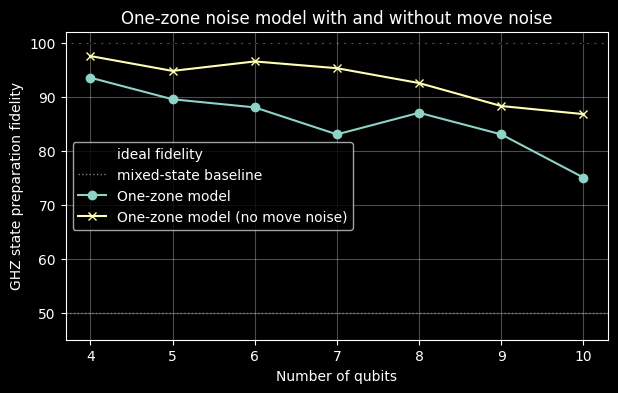

In [29]:
qubit_numbers = np.arange(4, 11, 1)
fidelities = []
fidelities_no_moves = []
for n_qubits in qubit_numbers:
    estimated_fidelity = estimate_ghz_overlap(n_qubits, one_noise_model, 200)
    fidelities.append(estimated_fidelity * 100)
    estimated_fidelity_no_moves = estimate_ghz_overlap(n_qubits, one_noise_model_no_moves, 400)
    fidelities_no_moves.append(estimated_fidelity_no_moves * 100)

plt.figure(figsize=(7, 4))
plt.axhline(100, color="black", linestyle="--", linewidth=1, label="ideal fidelity")
plt.axhline(50, color="gray", linestyle=":", linewidth=1, label="mixed-state baseline")
plt.plot(qubit_numbers, fidelities, marker="o", label="One-zone model")
plt.plot(qubit_numbers, fidelities_no_moves, marker="x", label="One-zone model (no move noise)")
plt.xlabel("Number of qubits")
plt.ylabel("GHZ state preparation fidelity")
plt.title("One-zone noise model with and without move noise")
plt.ylim(45, 102)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Conclusion

This marks the end of the second chapter. Revisiting our learning objectives, you should now be able to:

- **Use** the tools in QuEra's Bloqade to build and test quantum programs
- **Remember** the hierarchy for sources of error in neutral-atom programs
- **Reflect** on the design principles for efficient neutral-atom programs
- **Execute** noisy simulations with hardware-aware heuristic noise models